## Lato Sensu (2025) - I.A Generativa: Conceitos e Aplicações



  RNN-LSTM aplicada na estimativa da de preço de ações no mercado.



In [ ]:
# Célula 0 — Instalações


# Imports principais
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import random


In [ ]:
# Célula 1 — Configurações e hiperparâmetros
RNG_SEED = 42
np.random.seed(RNG_SEED)
tf.random.set_seed(RNG_SEED)
random.seed(RNG_SEED)

GITHUB_USER = "kalilurrahman"
GITHUB_REPO = "mastercardstockdata"
GITHUB_BRANCH = "main"
RAW_BASE = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/"
HISTORY_FILE = RAW_BASE + "Mastercard_stock_history.csv"

# Janela de entrada (timesteps)
WINDOW_SIZE = 60
# Modelo
RNN_TYPE = 'LSTM'
UNITS = 128
DROPOUT = 0.2
LR = 0.0001
EPOCHS = 80
BATCH_SIZE = 32

# Walk-forward config
retrain_every = 7      # retrain a cada N passos (1 = treina a cada dia)
use_log_returns = True # True = prever log-returns
multi_features = True  # usar features extras (ex: Open,High,Low,Volume,MAs)

print("Config OK")


Config OK


In [ ]:
# Célula 2 — Carregar dados e verificação
print("Tentando baixar:", HISTORY_FILE)
df = pd.read_csv(HISTORY_FILE)
print("Colunas:", df.columns.tolist())
# converter data e ordena
df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df['Date'] = df['Date'].dt.tz_convert(None)
df = df.sort_values('Date').reset_index(drop=True)
print("Período:", df['Date'].min(), "até", df['Date'].max())
display(df.head())


Tentando baixar: https://raw.githubusercontent.com/kalilurrahman/mastercardstockdata/main/Mastercard_stock_history.csv
Colunas: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
Período: 2006-05-25 04:00:00 até 2025-03-18 04:00:00


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2006-05-25 04:00:00,3.677800,4.202548,3.668674,4.197985,395343000,0.0,0.0
1,2006-05-26 04:00:00,4.225363,4.265517,4.025502,4.100336,103044000,0.0,0.0
2,2006-05-30 04:00:00,4.103990,4.104902,3.910517,4.015467,49898000,0.0,0.0
3,2006-05-31 04:00:00,4.047406,4.139579,4.047406,4.101250,30002000,0.0,0.0
4,2006-06-01 04:00:00,4.100334,4.389630,4.097596,4.335786,62344000,0.0,0.0


In [ ]:
# Célula 3 — Criar features básicas e log-returns (pré-processamento)
df = df.copy()
# features extras
df['Range'] = df['High'] - df['Low']
df['MA10'] = df['Close'].rolling(10).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['Close_shift1'] = df['Close'].shift(1)

# log prices and log returns (Para estabilizar série)
df['log_close'] = np.log(df['Close'])
df['log_return'] = df['log_close'].diff()

# remover os valores nulos ou que n são num gerados
df = df.dropna().reset_index(drop=True)
print("Após limpeza — período:", df['Date'].min(), "até", df['Date'].max())
df.tail(3)


Após limpeza — período: 2006-06-22 04:00:00 até 2025-03-18 04:00:00


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Range,MA10,MA20,Close_shift1,log_close,log_return
4711,2025-03-14 04:00:00,522.599976,528.409973,520.950012,527.640015,2369500,0.0,0.0,7.459961,541.991003,553.400006,519.830017,6.268414,0.014912
4712,2025-03-17 04:00:00,523.250000,533.479980,521.479980,531.989990,2544800,0.0,0.0,12.000000,537.698004,551.761505,527.640015,6.276625,0.008210
4713,2025-03-18 04:00:00,532.340027,532.590027,525.510010,528.354980,901928,0.0,0.0,7.080017,535.026501,549.748755,531.989990,6.269768,-0.006856


In [ ]:
# Célula 4 — Separar treino até 2020 e teste = 2021
train_end = pd.to_datetime("2020-12-31")
test_start = pd.to_datetime("2021-01-01")
test_end = pd.to_datetime("2021-12-31")

train_df = df[df['Date'] <= train_end].reset_index(drop=True)
test_df  = df[(df['Date'] >= test_start) & (df['Date'] <= test_end)].reset_index(drop=True)

print("Len treino:", len(train_df), "Len teste (2021):", len(test_df))
if test_df.empty:
    raise ValueError("Não foram encontrados dados para 2021 no CSV — verifique versão do dataset.")


Len treino: 3657 Len teste (2021): 251


In [ ]:
# Célula 5 — Funções utilitárias
def create_sequences(data_array, window_size):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:i+window_size])
        y.append(data_array[i+window_size])
    return np.array(X), np.array(y)

def build_rnn_model(input_shape, rnn_type='LSTM', units=128, dropout=0.2, lr=1e-4, output_dim=1):
    model = Sequential()
    if rnn_type == 'LSTM':
        model.add(LSTM(units, return_sequences=False, input_shape=input_shape))
    elif rnn_type == 'GRU':
        model.add(GRU(units, return_sequences=False, input_shape=input_shape))
    else:
        raise ValueError("rnn_type must be 'LSTM' or 'GRU'")
    model.add(Dropout(dropout))
    model.add(Dense(max(16, units//8), activation='relu'))
    model.add(Dense(output_dim))
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model


In [ ]:
# Célula 6 — Preparar arrays de features
if multi_features:
    features = ['Close','Open','High','Low','Volume','MA10','MA20','Range']
else:
    features = ['Close']  # univariado (você pode usar 'log_return')

# Para prever log_returns: target_col será 'log_return'
target_col = 'log_return' if use_log_returns else 'Close'

# dimensionar as funcionalidades e define os alvos para cada etapa da caminhada (o escalonador foi instalado no treino até aquele ponto)
print("Features:", features, "Target:", target_col)


Features: ['Close', 'Open', 'High', 'Low', 'Volume', 'MA10', 'MA20', 'Range'] Target: log_return


In [ ]:
# Célula 7 Walk-forward loop
predictions = []  # Monta as lista {Date, Predicted_Close, True_Close}
dates_test = list(test_df['Date'])

last_trained_until = None
current_model = None
feature_scaler = None
target_scaler = None

train_sizes = []
min_samples_to_train = 10  # mínimo de amostras (sequências)

def create_sequences_multifeat(arr_feat, arr_target, w):
    Xs, ys = [], []
    for j in range(len(arr_feat) - w):
        Xs.append(arr_feat[j:j+w, :])
        ys.append(arr_target[j+w, 0])
    if len(Xs) == 0:
        return np.empty((0, w, arr_feat.shape[1])), np.empty((0,))
    return np.array(Xs), np.array(ys)

for i, pred_date in enumerate(dates_test):
    # treinamento com dados até o dia anterior à predicao
    train_cutoff = pred_date - timedelta(days=1)
    train_window_df = df[df['Date'] <= train_cutoff].reset_index(drop=True)
    if train_window_df.empty:
        raise ValueError("Janela de treino vazia para data: " + str(pred_date))
    train_sizes.append(len(train_window_df))

    # decide se precisamos retrain
    need_retrain = (current_model is None) or (last_trained_until is None) or ((i % retrain_every) == 0)
    if need_retrain:
        # ajustar scalers com os dados até train_cutoff
        X_feat_all = train_window_df[features].values
        y_target_all = train_window_df[[target_col]].values

        feature_scaler = MinMaxScaler()
        target_scaler = MinMaxScaler()
        feature_scaler.fit(X_feat_all)
        target_scaler.fit(y_target_all)

        X_feats_scaled = feature_scaler.transform(X_feat_all)
        y_target_scaled = target_scaler.transform(y_target_all)

        # criar sequências (multifeature)
        Xs, ys = create_sequences_multifeat(X_feats_scaled, y_target_scaled, WINDOW_SIZE)

        # fallback: reduzir janela para tentar obter mais amostras
        if len(Xs) < min_samples_to_train:
            w_try = max(5, WINDOW_SIZE // 2)
            Xs, ys = create_sequences_multifeat(X_feats_scaled, y_target_scaled, w_try)
            if len(Xs) >= min_samples_to_train:
                print(f"[Aviso] poucos samples com WINDOW_SIZE={WINDOW_SIZE}. Usei window reduzida para {w_try} para treinar.")
            else:
                print(f"[Aviso] ainda poucos samples ({len(Xs)}) após reduzir janela para {w_try}.")

        # Se ainda não há samples suficientes para treinar:
        if len(Xs) < min_samples_to_train:
            if current_model is None:
                raise ValueError(f"Dados insuficientes para treinar (samples={len(Xs)}). Aumente janela histórica ou reduza WINDOW_SIZE.")
            else:
                # Reutiliza o modelo existente (não retraina)
                print(f"[Info] poucos samples ({len(Xs)}). Reutilizando modelo treinado anteriormente (sem retrain).")
        else:
            # treinar um novo modelo
            input_shape = (Xs.shape[1], Xs.shape[2])
            print(f"Retraining model for pred {pred_date.date()} — train samples: {Xs.shape[0]}, input_shape: {input_shape}")

            current_model = build_rnn_model(input_shape, rnn_type=RNN_TYPE, units=UNITS, dropout=DROPOUT, lr=LR, output_dim=1)

            callbacks = []
            if len(Xs) > 50:
                callbacks = [
                    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
                    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=0)
                ]

            current_model.fit(
                Xs, ys,
                validation_split=0.08 if len(Xs) > 50 else 0.0,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=callbacks,
                verbose=0,
                shuffle=False
            )
            last_trained_until = train_cutoff

    # preparar sequência mais recente para predicao (últimos WINDOW_SIZE rows)
    feats_for_pred = train_window_df[features].values[-WINDOW_SIZE:]
    if feats_for_pred.shape[0] < WINDOW_SIZE:
        pad_n = WINDOW_SIZE - feats_for_pred.shape[0]
        pad_arr = np.tile(feats_for_pred[0:1, :], (pad_n, 1))
        feats_for_pred = np.vstack([pad_arr, feats_for_pred])

    # escalar e reshape
    feats_scaled = feature_scaler.transform(feats_for_pred).reshape(1, WINDOW_size := WINDOW_SIZE, len(features))

    # prever com o modelo (caso current_model exista)
    if current_model is None:
        raise ValueError("current_model é None ao tentar prever — verifique dados e lógica de retrain.")
    pred_scaled = current_model.predict(feats_scaled, verbose=0)

    # converter de volta: pred_scaled -> log_return real -> price
    pred_logreturn = target_scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()[0]
    last_log_close = train_window_df['log_close'].iloc[-1]
    pred_log_price = last_log_close + pred_logreturn
    pred_price = float(np.exp(pred_log_price))

    # valor real (se tiver)
    true_row = df[df['Date'] == pred_date]
    true_price = float(true_row['Close'].values[0]) if not true_row.empty else np.nan

    predictions.append({
        'Date': pred_date,
        'Predicted_Close': pred_price,
        'True_Close': true_price
    })

print("Walk-forward done. Predictions:", len(predictions))


Retraining model for pred 2021-01-04 — train samples: 3598, input_shape: (60, 8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Retraining model for pred 2021-01-13 — train samples: 3605, input_shape: (60, 8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Retraining model for pred 2021-01-25 — train samples: 3612, input_shape: (60, 8)


...

Retraining model for pred 2021-12-13 — train samples: 3836, input_shape: (60, 8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Retraining model for pred 2021-12-22 — train samples: 3843, input_shape: (60, 8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Walk-forward done. Predictions: 251


In [ ]:
# Célula 8 — Converter resultados em DataFrame e avaliar (MAE, RMSE)
pred_df = pd.DataFrame(predictions)
pred_df = pred_df.sort_values('Date').reset_index(drop=True)
print(pred_df.head())

# Remove onde true é Nao numerico
eval_df = pred_df.dropna(subset=['True_Close']).copy()
y_true = eval_df['True_Close'].values
y_pred = eval_df['Predicted_Close'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"MAE (2021): {mae:.4f} | RMSE (2021): {rmse:.4f} | n={len(eval_df)}")


                 Date  Predicted_Close  True_Close
0 2021-01-04 05:00:00       348.475359  343.134491
1 2021-01-05 05:00:00       343.073182  339.161285
2 2021-01-06 05:00:00       339.119073  339.288147
3 2021-01-07 05:00:00       339.259262  341.976166
4 2021-01-08 05:00:00       342.088864  345.876312
MAE (2021): 4.7487 | RMSE (2021): 6.2214 | n=251


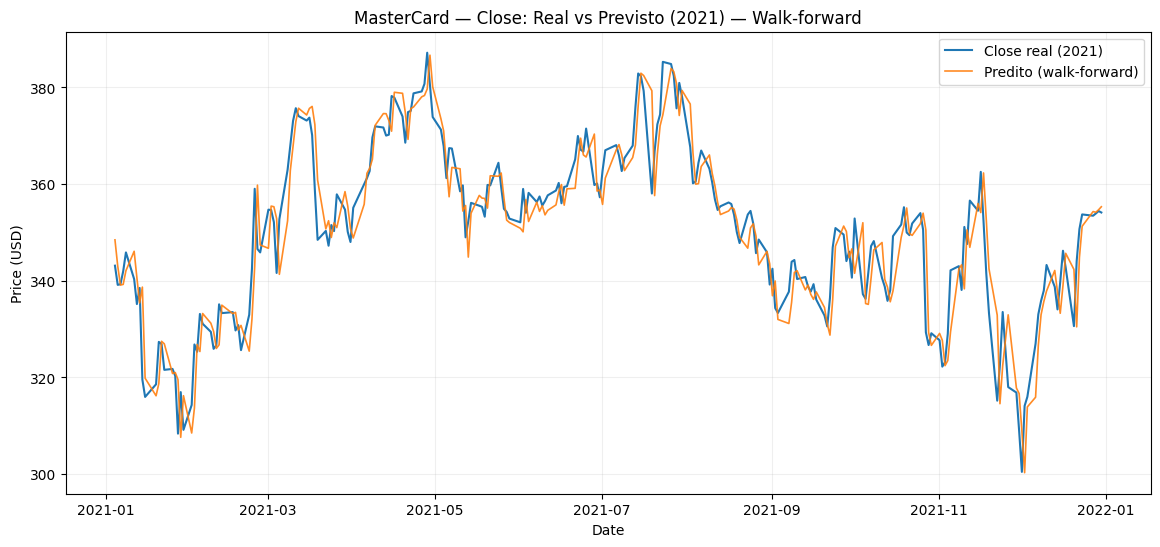

In [ ]:
# Célula 9 — Plot real vs previsto (2021)
plt.figure(figsize=(14,6))
plt.plot(eval_df['Date'], eval_df['True_Close'], label='Close real (2021)', linewidth=1.5)
plt.plot(pred_df['Date'], pred_df['Predicted_Close'], label='Predito (walk-forward)', linewidth=1.2, alpha=0.9)
plt.title("MasterCard — Close: Real vs Previsto (2021) — Walk-forward")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


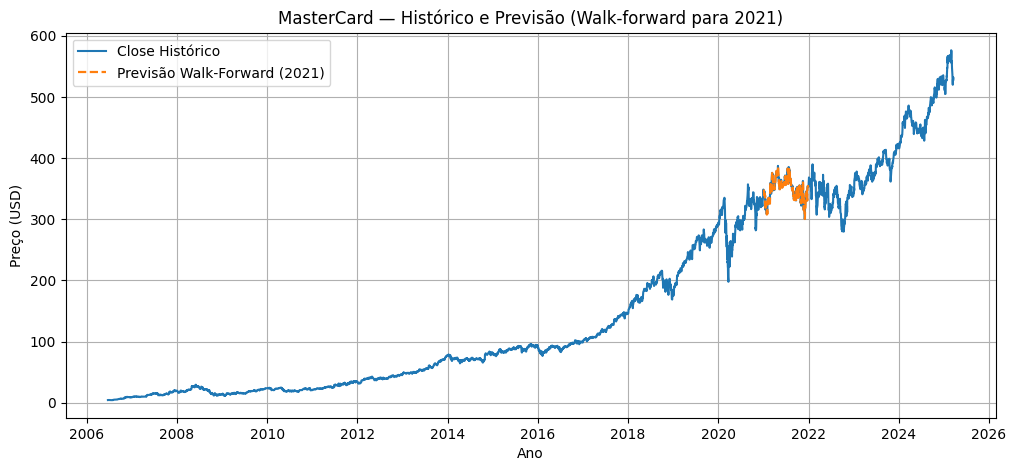

MAE (2021, onde real disponível): 4.7487
RMSE (2021, onde real disponível): 6.2214

 Análise:
- Média Close (últimos 12 meses históricos até 2020-12-31): 301.30
- Média Close prevista (2021): 349.73
- Variação média prevista vs históricos: +16.08% → tendência esperada: alta


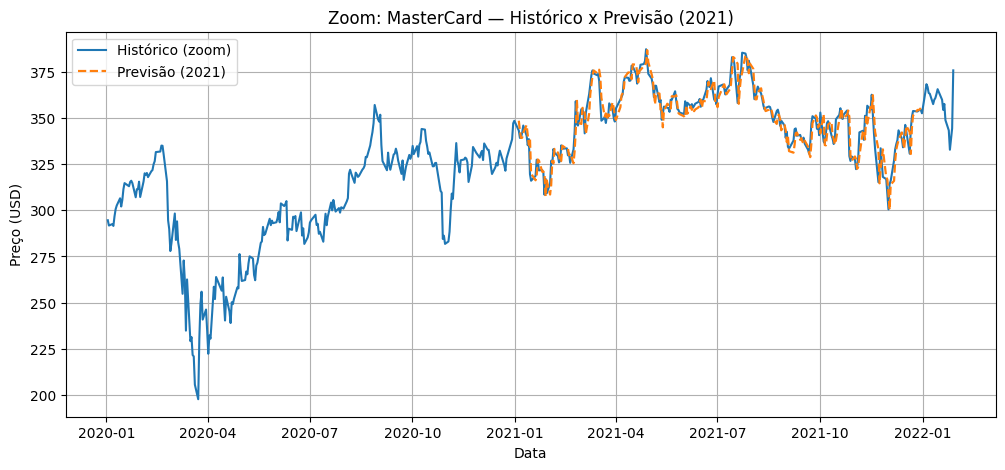

In [ ]:
# Célula 10  Plot histórico + previsão + análise
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Garantir que 'df' contenha ['Date','Close'] e 'pred_df' tenha ['Date','Predicted_Close','True_Close'] se n da erro
# Converter Date para datetime e indexar historico por Date
hist_df = df[['Date','Close']].copy()
hist_df['Date'] = pd.to_datetime(hist_df['Date'])
hist_df = hist_df.set_index('Date').sort_index()

# Previsões walk-forward
wf_df = pd.DataFrame(predictions) if 'predictions' in globals() else pred_df.copy()
wf_df['Date'] = pd.to_datetime(wf_df['Date'])
wf_df = wf_df.sort_values('Date').reset_index(drop=True)

# Criar série de previsões indexada por Data
pred_series = pd.Series(wf_df['Predicted_Close'].values, index=wf_df['Date'])

# Plot: histórico completo (linha contínua) + prev
plt.figure(figsize=(12,5))
plt.plot(hist_df.index, hist_df['Close'], label='Close Histórico', linewidth=1.5)
plt.plot(pred_series.index, pred_series.values, '--', label='Previsão Walk-Forward (2021)', linewidth=1.6)
plt.title("MasterCard — Histórico e Previsão (Walk-forward para 2021)")
plt.xlabel("Ano")
plt.ylabel("Preço (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Avaliação usando apenas datas onde temos valor real (True_Close não-Nao Num)
eval_df = wf_df.dropna(subset=['True_Close']).copy()
if len(eval_df) > 0:
    y_true = eval_df['True_Close'].values
    y_pred = eval_df['Predicted_Close'].values
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"MAE (2021, onde real disponível): {mae:.4f}")
    print(f"RMSE (2021, onde real disponível): {rmse:.4f}")
else:
    print("Não há valores reais disponíveis nas datas previstas para cálculo de MAE/RMSE.")

# Estatística comparativa / análise textual
last_train_date = pd.to_datetime(train_end)  # 'train_end' definido no notebook: 2020-12-31
# pegar o slice de 12 meses anteriores a last_train_date
start_last12 = last_train_date - pd.DateOffset(months=12)
last12_hist = hist_df.loc[start_last12:last_train_date]['Close']

# Média real dos últimos 12 meses e média prevista para 2021 (previsão do walk-forward)
mean_last12 = last12_hist.mean() if len(last12_hist) > 0 else np.nan
mean_pred_2021 = pred_series.mean() if len(pred_series) > 0 else np.nan

print("\n Análise:")
print(f"- Média Close (últimos 12 meses históricos até {last_train_date.date()}): {mean_last12:.2f}")
print(f"- Média Close prevista (2021): {mean_pred_2021:.2f}")

if not np.isnan(mean_last12) and not np.isnan(mean_pred_2021):
    variation_pct = (mean_pred_2021 - mean_last12) / mean_last12 * 100
    trend = "alta" if variation_pct > 0 else "queda" if variation_pct < 0 else "estável"
    print(f"- Variação média prevista vs históricos: {variation_pct:+.2f}% → tendência esperada: {trend}")
else:
    print("- Não foi possível calcular a variação (faltam dados históricos ou previsões).")


try:
    plt.figure(figsize=(12,5))
    # plot histórico apenas no intervalo próximo a 2021
    zoom_start = pd.to_datetime("2020-01-01")
    zoom_end = pd.to_datetime("2022-01-31")
    plt.plot(hist_df.loc[zoom_start:zoom_end].index, hist_df.loc[zoom_start:zoom_end]['Close'], label='Histórico (zoom)', linewidth=1.5)
    plt.plot(pred_series.index, pred_series.values, '--', label='Previsão (2021)', linewidth=1.6)
    plt.title("Zoom: MasterCard — Histórico x Previsão (2021)")
    plt.xlabel("Data")
    plt.ylabel("Preço (USD)")
    plt.legend()
    plt.grid(True)
    plt.show()
except Exception as e:
    print("Erro ao desenhar zoom plot:", e)


*Como foi contruido a proposta de Solução de problema: (Story Teling)*

---



## Bloco 0

Importa todas as bibliotecas essenciais

NumPy e Pandas: manipulação de dados e séries temporais.

Matplotlib: visualização dos resultados.

Scikit-Learn: normalização e métricas de erro.

TensorFlow/Keras: construção e treino da rede neural (nesse modelo usamos LSTM).

Define as bases para o ambiente de aprendizado de máquina.


## Bloco 1


Define parâmetros do experimento, garantindo reprodutibilidade e controle dos resultados.

Configurações:

Tamanho da janela temporal (WINDOW_SIZE = 60 dias).

Tipo de rede (LSTM).

Número de neurônios, taxa de dropout e taxa de aprendizado.

Estabelece também a forma de obtenção dos dados via GitHub, o que garante a automatização da coleta.


## Bloco 2


"Lê" o dataset diretamente do repositório GitHub.

Converte a coluna Date para o formato de data e ordena cronologicamente.

Exibe as primeiras linhas e o intervalo temporal do dataset.



# Bloco 3


Cria novas variáveis (features) para enriquecer o aprendizado:

Range (volatilidade diária),

Médias móveis (MA10, MA20) para captar tendências,

Retornos logarítmicos (log_return) para estabilizar a série e reduzir
heterocedasticidade.

Remove valores nulos gerados nas transformações.


## Bloco 4


Divide o dataset temporalmente, garantindo que o modelo aprenda somente com dados passados.

O conjunto de teste (2021) é usado apenas para previsão, simulando o futuro real.


## Bloco 5


Define funções reutilizáveis:

create_sequences(): transforma os dados em janelas de tempo para a RNN.

build_rnn_model(): monta a arquitetura da rede neural, configurando camadas LSTM, Dropout e Dense.


## Bloco 6


Define quais variáveis o modelo vai usar para aprender o padrão do preço.

Escolhe o alvo (target) como log_return (variação logarítmica diária do preço), por ser mais estável e aplica a normalização Min-Max.



## Bloco 7


Para cada dia de 2021:

Usa todos os dados até o dia anterior para treinar ou atualizar o modelo.

Cria janelas de entrada (ex: últimos 60 dias) e gera a previsão do dia seguinte.

Reentreina o modelo a cada n dias (retrain_every=7).

Faz a previsão incremental (sem olhar o futuro) ficando próximo a modelos usados comercialmente.


## Bloco 8


Mede o erro médio absoluto (MAE) e o erro quadrático médio (RMSE) das previsões de 2021.

Permite avaliar quão próxima a previsão ficou da realidade.


## Bloco 9


Plota  a  Visualização: Real vs Previsto (2021).


## Bloco 10


Análise final e comparação histórica


Mostra o histórico completo + previsões.

Calcula a média de preços do último ano real (2020) e a média prevista para 2021.

Estima a tendência esperada (alta, queda ou estabilidade).

Gera gráficos adicionais com zoom em 2021.
